# 🧬 Parkinson’s Disease Detection using Keystroke Dynamics

This project uses machine learning to detect early-stage Parkinson’s Disease based on typing behaviour (keystroke dynamics).

We apply feature selection, class balancing, and multiple models to achieve high classification accuracy.

## 📦 Import Libraries

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import SelectKBest, chi2
from scipy.stats import pearsonr
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC


## 📊 Load and Merge Dataset

In [6]:
from pathlib import Path

BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data"

tappy_data_path = DATA_DIR / "Tappy Data"
user_data_path = DATA_DIR / "Archived users"

In [7]:
directory_path = tappy_data_path

df_all_tappy_data = pd.DataFrame()

for filename in os.listdir(directory_path):
    if filename.endswith('.txt'):
        file_path = os.path.join(directory_path, filename)
        df = pd.read_csv(file_path, delimiter=r'\s+', header=None,
                         names=['UserKey', 'Date', 'Timestamp', 'Hand', 'Holdtime', 'Direction', 'Latencytime', 'Flighttime'], low_memory=False)
        for col in ['Holdtime', 'Latencytime', 'Flighttime']:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        df_all_tappy_data = pd.concat([df_all_tappy_data, df], ignore_index=True)

df_all_tappy_data

,UserKey,Date,Timestamp,Hand,Holdtime,Direction,Latencytime,Flighttime
0,NMMGWRY6SO,170301,08:45:42.125,L,187.5,LL,421.9,281.3
1,NMMGWRY6SO,170301,08:45:42.422,L,203.1,LL,281.3,93.8
2,NMMGWRY6SO,170301,08:48:29.031,L,203.1,LL,296.9,125.0
3,NMMGWRY6SO,170301,08:48:29.266,L,218.8,LL,218.8,15.6
4,NMMGWRY6SO,170301,08:48:29.484,R,187.5,LR,250.0,31.3
...,...,...,...,...,...,...,...,...
9316853,3HYXJCTCNT,170126,14:12:47.000,S,58.6,RS,214.8,160.2
9316854,3HYXJCTCNT,170126,14:12:49.422,R,85.9,LR,175.8,82.0
9316855,3HYXJCTCNT,170126,14:12:49.598,R,39.1,RR,222.7,136.7
9316856,3HYXJCTCNT,170126,14:12:51.160,L,43.0,LL,125.0,285.2


In [8]:
directory_path = user_data_path

df_all_user_data = pd.DataFrame()

for filename in os.listdir(directory_path):
    if filename.endswith('.txt') and filename.startswith('User_'):
        file_path = os.path.join(directory_path, filename)
        user_key = filename.replace('User_', '').replace('.txt', '')
        data = {}
        with open(file_path, 'r') as file:
            for line in file:
                key, value = line.strip().split(':')
                data[key.strip()] = value.strip()
        df = pd.DataFrame([data])
        df['UserKey'] = user_key
        df_all_user_data = pd.concat([df_all_user_data, df], ignore_index=True)

df_all_user_data


,BirthYear,Gender,Parkinsons,Tremors,DiagnosisYear,Sided,UPDRS,Impact,Levadopa,DA,MAOB,Other,UserKey
0,,Male,True,True,,Left,Don't know,Mild,True,False,False,False,PJU53Y7KVB
1,1952,Male,False,False,------,None,Don't know,------,False,False,False,False,G6OE5CXQPY
2,1951,Male,True,True,2003,Left,Don't know,Severe,True,False,False,False,2X17VCRRQA
3,1947,Female,True,True,2014,None,Don't know,Medium,True,False,False,True,I3U47MF5UF
4,1965,Male,True,True,2007,Right,Don't know,Severe,True,False,True,False,L7Q16SJ7KP
...,...,...,...,...,...,...,...,...,...,...,...,...,...
222,1946,Female,True,True,2012,Left,Don't know,Medium,True,False,False,True,VIAXR21TSC
223,1943,Female,True,True,2013,None,Don't know,Mild,True,False,False,False,IDZHIUK2W2
224,1953,Male,True,True,2016,None,Don't know,Severe,True,False,False,True,SW61HF6XRY
225,1958,Male,True,True,2013,Right,Don't know,Medium,True,False,False,False,2JTCBKUP8T


## 🧹 Data Preprocessing
- Handling missing values  
- Removing duplicates  
- Outlier removal (IQR)  
- Feature scaling  

In [10]:
missing_keys = df_all_tappy_data[~df_all_tappy_data['UserKey'].isin(df_all_user_data['UserKey'])]['UserKey'].unique()
print(f"Number of unique UserKeys in tappy data without a match in user data: {len(missing_keys)}")


Number of unique UserKeys in tappy data without a match in user data: 116


In [11]:
df_missing_userkeys = df_all_tappy_data[df_all_tappy_data['UserKey'].isin(missing_keys)]

print(df_missing_userkeys.describe(include='all'))

           UserKey    Date     Timestamp    Hand      Holdtime Direction  \
count       302059  302060        302060  302060  3.019870e+05    302060   
unique         115     292        297547      58           NaN        49   
top     QEYMRM1ZSM  160813  10:23:18.125       L           NaN        LL   
freq        221752    8810             3  143666           NaN     64954   
mean           NaN     NaN           NaN     NaN  1.538577e+02       NaN   
std            NaN     NaN           NaN     NaN  1.811258e+04       NaN   
min            NaN     NaN           NaN     NaN  0.000000e+00       NaN   
25%            NaN     NaN           NaN     NaN  8.980000e+01       NaN   
50%            NaN     NaN           NaN     NaN  1.172000e+02       NaN   
75%            NaN     NaN           NaN     NaN  1.484000e+02       NaN   
max            NaN     NaN           NaN     NaN  9.947047e+06       NaN   

          Latencytime     Flighttime  
count   301966.000000  301985.000000  
unique   

In [12]:
df_merged_tappy_and_user = pd.merge(df_all_tappy_data, df_all_user_data, on='UserKey', how='inner')

print(df_merged_tappy_and_user.head())
print(f"The dataset after inner join has {df_merged_tappy_and_user.shape[0]} rows.")


      UserKey    Date     Timestamp Hand  Holdtime Direction  Latencytime  \
0  NMMGWRY6SO  170301  08:45:42.125    L     187.5        LL        421.9   
1  NMMGWRY6SO  170301  08:45:42.422    L     203.1        LL        281.3   
2  NMMGWRY6SO  170301  08:48:29.031    L     203.1        LL        296.9   
3  NMMGWRY6SO  170301  08:48:29.266    L     218.8        LL        218.8   
4  NMMGWRY6SO  170301  08:48:29.484    R     187.5        LR        250.0   

   Flighttime BirthYear Gender Parkinsons Tremors DiagnosisYear  Sided  \
0       281.3      1948   Male       True   False          2016  Right   
1        93.8      1948   Male       True   False          2016  Right   
2       125.0      1948   Male       True   False          2016  Right   
3        15.6      1948   Male       True   False          2016  Right   
4        31.3      1948   Male       True   False          2016  Right   

        UPDRS Impact Levadopa     DA   MAOB  Other  
0  Don't know   Mild    False  False  F

In [13]:
print(df_merged_tappy_and_user['UserKey'].nunique())

217


In [14]:
df = df_merged_tappy_and_user

# Filtering rows to check
df_parkinsons_dash = df[(df['Levadopa'] == 'False') & (df['Impact'] == 'Mild')]

print(f"Number of records: {len(df_parkinsons_dash)}")


Number of records: 1250263


Descriptive Statistics for Holdtime, Latencytime, and Flighttime:
           Holdtime   Latencytime    Flighttime
count  9.014491e+06  9.014380e+06  9.014499e+06
mean   7.810403e+01  2.605852e+02  1.881616e+02
std    6.458440e+04  3.473011e+02  5.699308e+02
min   -8.639992e+07  1.000000e+00  0.000000e+00
25%    7.810000e+01  1.641000e+02  9.380000e+01
50%    1.016000e+02  2.305000e+02  1.602000e+02
75%    1.367000e+02  3.242000e+02  2.500000e+02
max    1.359442e+07  1.702050e+05  1.703010e+05

Skewness of Holdtime, Latencytime, and Flighttime:
Holdtime      -1326.872246
Latencytime     392.107012
Flighttime      271.353213
dtype: float64

Kurtosis of Holdtime, Latencytime, and Flighttime:
Holdtime       1.776745e+06
Latencytime    1.826765e+05
Flighttime     7.757811e+04
dtype: float64


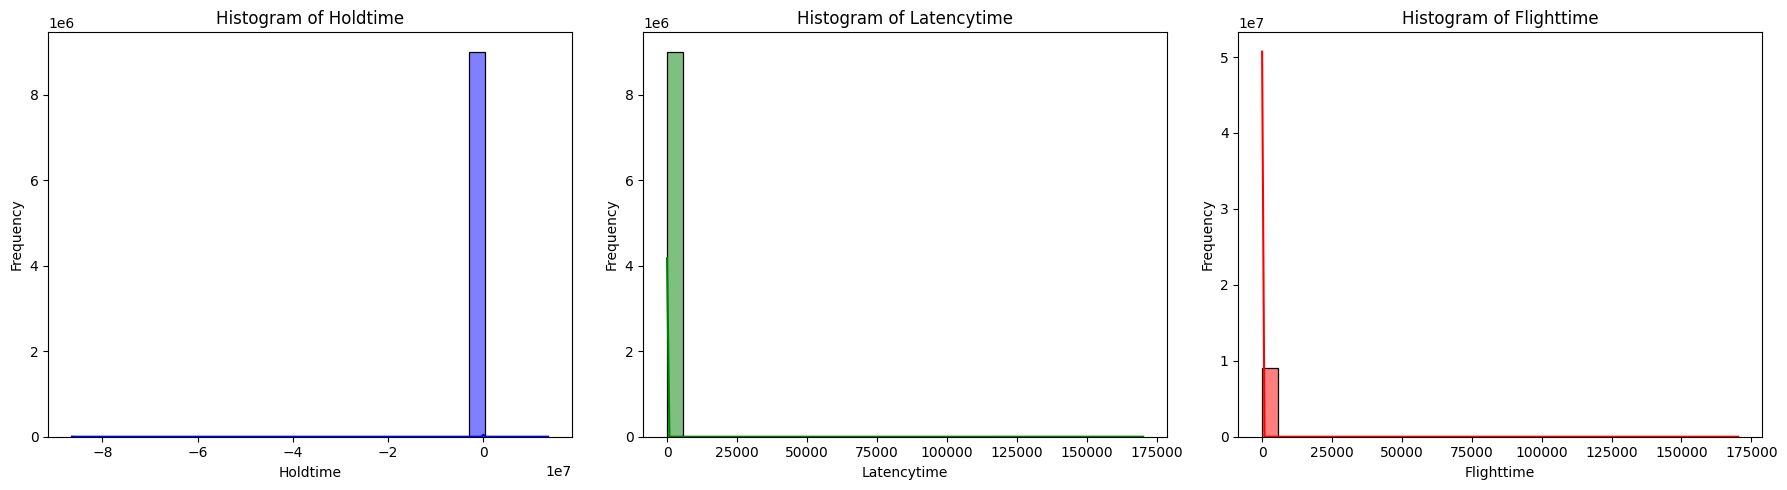

In [15]:
# Descriptive Statistics for Numerical Features
descriptive_stats = df[['Holdtime', 'Latencytime', 'Flighttime']].describe()
print("Descriptive Statistics for Holdtime, Latencytime, and Flighttime:")
print(descriptive_stats)

# Additional Statistics
# Skewness
skewness = df[['Holdtime', 'Latencytime', 'Flighttime']].skew()
print("\nSkewness of Holdtime, Latencytime, and Flighttime:")
print(skewness)

# Kurtosis
kurtosis = df[['Holdtime', 'Latencytime', 'Flighttime']].kurtosis()
print("\nKurtosis of Holdtime, Latencytime, and Flighttime:")
print(kurtosis)

# Histograms for Hold Time, Latency Time, and Flight Time
plt.figure(figsize=(18, 5))

# Plotting histogram for Holdtime
plt.subplot(1, 3, 1)
sns.histplot(df['Holdtime'], kde=True, bins=30, color='blue')
plt.title('Histogram of Holdtime')
plt.xlabel('Holdtime')
plt.ylabel('Frequency')

# Plotting histogram for Latencytime
plt.subplot(1, 3, 2)
sns.histplot(df['Latencytime'], kde=True, bins=30, color='green')
plt.title('Histogram of Latencytime')
plt.xlabel('Latencytime')
plt.ylabel('Frequency')

# Plotting histogram for Flighttime
plt.subplot(1, 3, 3)
sns.histplot(df['Flighttime'], kde=True, bins=30, color='red')
plt.title('Histogram of Flighttime')
plt.xlabel('Flighttime')
plt.ylabel('Frequency')

# Display the plots
plt.tight_layout()
plt.show()

In [ ]:
df = df_merged_tappy_and_user

# Combining '------' and '' into 'Mild' in the 'Impact' column
df['Impact'] = df['Impact'].replace(['------', ''], 'Mild')

# Filtering out users with fewer than 2000 keystrokes
user_counts = df['UserKey'].value_counts()
filtered_users = user_counts[user_counts >= 2000].index
df_filtered = df[df['UserKey'].isin(filtered_users)]
print(f"Number of users after filtering for keystrokes: {df_filtered['UserKey'].nunique()}")

# Filtering for 'Mild' and 'Medium' severity in the 'Impact' column
#df_filtered_mild = df_filtered[df_filtered['Impact'] == 'Mild']
df_filtered_mild = df_filtered[df_filtered['Impact'].isin(['Mild', 'Medium'])]
print(f"Number of users after filtering for 'Mild' severity: {df_filtered_mild['UserKey'].nunique()}")

# Filtering out those taking Levodopa
df_filtered_combined = df_filtered_mild[df_filtered_mild['Levadopa'] == 'False']
print(f"Number of users after filtering out Levodopa: {df_filtered_combined['UserKey'].nunique()}")


In [ ]:
steps = [
    "Total Users",
    "Users After Keystrokes Filtering",
    "Users After 'Mild' Severity Filtering",
    "Users After Levodopa Filtering"
]

user_counts = [217, 131, 118, 64]

# Plotting the bar chart
plt.figure(figsize=(12, 7))
bars = plt.bar(steps, user_counts, color='#4A90E2', edgecolor='black', linewidth=1.2)

# Adding the value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 3, int(yval), ha='center', va='bottom', fontsize=12, fontweight='bold')

# Enhancing the visual appeal
plt.xlabel('Filtering Steps', fontsize=14, fontweight='bold')
plt.ylabel('Number of Users', fontsize=14, fontweight='bold')
plt.title('User Reduction After Each Filtering Step', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, fontsize=12, ha="right")
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.savefig("../results/user_reduction_bar_chart.png")
plt.show()


In [ ]:
# Group split based on UserKey
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(df_filtered_combined, groups=df_filtered_combined['UserKey']))

train_data = df_filtered_combined.iloc[train_idx]
test_data = df_filtered_combined.iloc[test_idx]

# Verifying the split to ensure no overlap in UserKey
train_user_keys = set(train_data['UserKey'])
test_user_keys = set(test_data['UserKey'])
overlap = train_user_keys.intersection(test_user_keys)

print(f"Number of unique UserKeys in training set: {len(train_user_keys)}")
print(f"Number of unique UserKeys in test set: {len(test_user_keys)}")
print(f"Number of overlapping UserKeys between training and test sets: {len(overlap)}")

In [ ]:
sets = ['Training Set', 'Test Set']
user_counts = [44, 20]  # These values are based on the code output

# Plotting the bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(sets, user_counts, color=['#1f77b4', '#ff7f0e'], edgecolor='black', linewidth=1.2)

# Adding the value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', va='bottom', fontsize=12, fontweight='bold')

# Enhancing the visual appeal
plt.xlabel('Data Sets', fontsize=14, fontweight='bold')
plt.ylabel('Number of Unique Users', fontsize=14, fontweight='bold')
plt.title('Number of Unique Users in Training and Test Sets', fontsize=16, fontweight='bold')
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, max(user_counts) + 5)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.savefig("../results/unique_users_training_vs_test_sets.png")
plt.show()


In [ ]:
import pandas as pd

# Checking for overlapping rows between training and test sets
overlap = pd.merge(train_data, test_data, how='inner')
if not overlap.empty:
    print("Warning: Data leakage detected!")
else:
    print("No data leakage detected.")


In [ ]:
print(train_data.nunique())

In [ ]:
print(test_data.nunique())

In [ ]:
# Checking and Removing duplicates in training data
train_duplicates = train_data.duplicated()
num_train_duplicates = train_duplicates.sum()
print(f"Number of duplicate rows in training data: {num_train_duplicates}")

# Removing duplicates in training data
train_data = train_data.drop_duplicates()

# Verifying duplicates have been removed in training data
train_duplicates_after_removal = train_data.duplicated().sum()
print(f"Number of duplicate rows in training data after removal: {train_duplicates_after_removal}")

# Checking and Removing Duplicates in test data
test_duplicates = test_data.duplicated()
num_test_duplicates = test_duplicates.sum()
print(f"Number of duplicate rows in test data: {num_test_duplicates}")

# Removing duplicates in test data
test_data = test_data.drop_duplicates()

# Verifying duplicates have been removed in test data
test_duplicates_after_removal = test_data.duplicated().sum()
print(f"Number of duplicate rows in test data after removal: {test_duplicates_after_removal}")



In [ ]:
# Checking for missing values in all columns in the training set
missing_train_all = train_data.isnull().sum()
print('Missing values in the training set:')
print(missing_train_all)

# Checking for missing values in all columns in the test set
missing_test_all = test_data.isnull().sum()
print('Missing values in the test set:')
print(missing_test_all)


In [ ]:
# Defining columns to impute
columns_to_impute = ['Holdtime', 'Latencytime', 'Flighttime']

median_values = {}
for col in columns_to_impute:
    median_train = train_data[col].median()
    median_values[col] = median_train
    train_data[col].fillna(median_train, inplace=True)
    test_data[col].fillna(median_train, inplace=True)  # Using the same median as the training set for consistency


# Output the median values used for imputation
print("\nMedian values used for imputation:")
for col, median in median_values.items():
    print(f"{col}: {median}")

# Verifying missing values are imputed in training and test set

missing_train_after_imputation = train_data.isnull().sum()
print("\nMissing values in training data after imputation:")
print(missing_train_after_imputation[missing_train_after_imputation > 0])

missing_test_after_imputation = test_data.isnull().sum()
print("\nMissing values in test data after imputation:")
print(missing_test_after_imputation[missing_test_after_imputation > 0])

In [ ]:
print(train_data.count())
print(test_data.count())

In [ ]:
# Removing outliers
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

columns_to_check = ['Holdtime', 'Latencytime', 'Flighttime']

# Removing outliers in training data
print(f"\nShape of training data before removing outliers: {train_data.shape}")
train_data = remove_outliers(train_data, columns_to_check)
print(f"Shape of training data after removing outliers: {train_data.shape}")

# Removing outliers in test data
print(f"\nShape of test data before removing outliers: {test_data.shape}")
test_data = remove_outliers(test_data, columns_to_check)
print(f"Shape of test data after removing outliers: {test_data.shape}")

print("\nData after removing outliers:")
print("Training data:")
print(train_data.describe())
print("\nTest data:")
print(test_data.describe())


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Applying Min-Max Scaling
scaler = MinMaxScaler()

# Fitting the scaler on the training data
train_data[columns_to_check] = scaler.fit_transform(train_data[columns_to_check])

# Applying the scaler to the test data
test_data[columns_to_check] = scaler.transform(test_data[columns_to_check])

print("\nTraining data after scaling:")
print(train_data.describe())
print("\nTest data after scaling:")
print(test_data.describe())


In [ ]:
# Categorical columns to inspect
categorical_columns = ['Hand', 'Direction', 'Gender', 'UPDRS', 'Impact', 'Levadopa', 'DA', 'MAOB', 'Other', 'Parkinsons']

# Inspecting unique values in each categorical column in training set
for column in categorical_columns:
    unique_values = train_data[column].unique()
    print(f'Unique values in {column}: {unique_values}')


In [ ]:
# Categorical columns to inspect
categorical_columns = ['Hand', 'Direction', 'Gender', 'UPDRS', 'Impact', 'Levadopa', 'DA', 'MAOB', 'Other', 'Parkinsons']

# Inspecting unique values in each categorical column in test set
for column in categorical_columns:
    unique_values = test_data[column].unique()
    print(f'Unique values in {column}: {unique_values}')


In [ ]:
# Defining valid entries for categorical columns
valid_entries = {
    'Hand': ['S', 'L', 'R'],
    'Direction': ['LL', 'LR', 'RL', 'RR', 'LS', 'RS', 'SS', 'SR', 'SL'],
}

# Filtering categorical columns in training data
for column, valid_values in valid_entries.items():
    train_data = train_data[train_data[column].isin(valid_values)]

# Filtering categorical columns in test data
for column, valid_values in valid_entries.items():
    test_data = test_data[test_data[column].isin(valid_values)]

print("\nTraining data after filtering categorical columns:")
print(train_data.describe(include='all'))
print("\nTest data after filtering categorical columns:")
print(test_data.describe(include='all'))

In [ ]:
print(f'Training set shape after cleaning: {train_data.shape}')
print(f'Test set shape after cleaning: {test_data.shape}')

In [ ]:
print(train_data.head())

In [ ]:
# Inspecting unique values in the 'BirthYear' column
unique_birth_years_train = train_data['BirthYear'].unique()
unique_birth_years_test = test_data['BirthYear'].unique()

print(f'Unique values in BirthYear (train): {unique_birth_years_train}')
print(f'Unique values in BirthYear (test): {unique_birth_years_test}')


In [ ]:
# Converting 'BirthYear' to numeric, forcing errors to NaN
train_data['BirthYear'] = pd.to_numeric(train_data['BirthYear'], errors='coerce')
test_data['BirthYear'] = pd.to_numeric(test_data['BirthYear'], errors='coerce')

# Imputing missing 'BirthYear' with median
median_birth_year_train = train_data['BirthYear'].median()
train_data['BirthYear'].fillna(median_birth_year_train, inplace=True)
test_data['BirthYear'].fillna(median_birth_year_train, inplace=True)  # Use the same median as the training set for consistency

# Output the median value used for BirthYear imputation
print(f"\nMedian value used for BirthYear imputation: {median_birth_year_train}")

# Calculating 'Age' column as the data was collected in 2017
current_year = 2017
train_data['Age'] = current_year - train_data['BirthYear']
test_data['Age'] = current_year - test_data['BirthYear']

# Creating 'Age_Group' column
train_data['Age_Group'] = (train_data['Age'] >= 60).astype(int)
test_data['Age_Group'] = (test_data['Age'] >= 60).astype(int)

print("\nShape of training data after handling 'BirthYear':")
print(train_data.shape)
print("\nShape of test data after handling 'BirthYear':")
print(test_data.shape)


## 🧠 Feature Engineering
- Age and age group creation  
- Encoding categorical variables  

In [ ]:
def plot_age_groups(train_data, test_data):
    plt.figure(figsize=(14, 7))

    # Define age groups based on age 60 directly for visualization
    train_age_group = train_data['Age'].apply(lambda x: '60+' if x >= 60 else 'Below 60')
    test_age_group = test_data['Age'].apply(lambda x: '60+' if x >= 60 else 'Below 60')

    # Combine the age groups for plotting
    combined_age_groups = pd.concat([train_age_group, test_age_group])

    # Count plot for age groups
    sns.countplot(x=combined_age_groups, order=['Below 60', '60+'])
    plt.title('Count of Age Groups in Dataset')
    plt.xlabel('Age Group')
    plt.ylabel('Count')

    # Show the plot
    plt.savefig("../results/age_group_distribution.png")
    plt.show()

# Call the function to plot data without modifying the original DataFrame
plot_age_groups(train_data, test_data)



In [ ]:
def plot_age_distribution(train_data, test_data):
    plt.figure(figsize=(12, 6))

    # Combine both datasets for a comprehensive plot
    combined_ages = pd.concat([train_data['Age'], test_data['Age']], axis=0)

    # Creating a histogram of age distribution
    sns.histplot(combined_ages, bins=20, kde=False, color='skyblue')
    plt.axvline(x=60, color='red', linestyle='--', label='Age 60 demarcation')
    plt.title('Age Distribution in Dataset')
    plt.xlabel('Age')
    plt.ylabel('Frequency')
    plt.legend()

    # Show the plot
    plt.savefig("../results/age_distribution_60_threshold.png")
    plt.show()

# Call the function to plot data without modifying the original DataFrame
plot_age_distribution(train_data, test_data)



In [ ]:
# One-Hot Encoding for 'Hand', 'Direction', and 'Sided' Columns
categorical_columns = ['Hand', 'Direction', 'Sided']

train_data = pd.get_dummies(train_data, columns=categorical_columns)
test_data = pd.get_dummies(test_data, columns=categorical_columns)

# Ensuring both train and test have the same columns after one-hot encoding
train_data, test_data = train_data.align(test_data, join='inner', axis=1)

print("\nShape of training data after one-hot encoding:")
print(train_data.shape)
print("\nShape of test data after one-hot encoding:")
print(test_data.shape)


In [ ]:
print(train_data.head())

In [ ]:
# List of columns to convert to 0 and 1
columns_to_convert = ['Parkinsons', 'Tremors', 'DA', 'MAOB', 'Other']

# Function to convert strings to binary values
def convert_to_binary(value):
    value = str(value).strip().lower()  # Converting to string, strip whitespace, and convert to lowercase
    if value in ['yes', 'true', '1', 'positive']:
        return 1
    else:
        return 0

# Converting specified columns in train_data
for column in columns_to_convert:
    train_data[column] = train_data[column].apply(convert_to_binary)

# Converting specified columns in test_data
for column in columns_to_convert:
    test_data[column] = test_data[column].apply(convert_to_binary)

# Converting all boolean columns to 0 and 1 in train_data
boolean_columns = train_data.select_dtypes(include=['bool']).columns
train_data[boolean_columns] = train_data[boolean_columns].astype(int)

# Converting all boolean columns to 0 and 1 in test_data
boolean_columns = test_data.select_dtypes(include=['bool']).columns
test_data[boolean_columns] = test_data[boolean_columns].astype(int)

print(train_data.head())
print(test_data.head())


In [ ]:
print(train_data.nunique())

In [ ]:
# Function to convert gender to binary values
def convert_gender_to_binary(value):
    value = str(value).strip().lower()  # Convert to string, strip whitespace, and convert to lowercase
    if value == 'male':
        return 0
    else:
        return 1

# Converting 'Gender' column in train_data
train_data['Gender'] = train_data['Gender'].apply(convert_gender_to_binary)

# Converting 'Gender' column in test_data
test_data['Gender'] = test_data['Gender'].apply(convert_gender_to_binary)

print(train_data[['Gender']].head())
print(test_data[['Gender']].head())


In [ ]:
# Assuming your train_data and test_data have already been processed to have a 'Gender' column with binary values
# Calculate gender counts for training data
train_gender_counts = train_data['Gender'].value_counts()

# Calculate gender counts for test data
test_gender_counts = test_data['Gender'].value_counts()

# Now plotting
import matplotlib.pyplot as plt
import seaborn as sns

def add_labels(ax):
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.0f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')

# Plotting the gender distribution for training data
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=train_gender_counts.index, y=train_gender_counts.values, palette="Set2")
add_labels(ax)
plt.title('Gender Distribution in Training Data')
plt.ylabel('Count')
plt.ylim(0, max(train_gender_counts.values) * 1.1)  # Adjust the y-axis limit for better spacing
plt.savefig("../results/gender_distribution_training.png")
plt.show()

# Plotting the gender distribution for test data
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=test_gender_counts.index, y=test_gender_counts.values, palette="Set2")
add_labels(ax)
plt.title('Gender Distribution in Test Data')
plt.ylabel('Count')
plt.ylim(0, max(test_gender_counts.values) * 1.1)  # Adjust the y-axis limit for better spacing
plt.savefig("../results/gender_distribution_test.png")
plt.show()



In [ ]:
print(test_data.nunique())

In [ ]:
print(f'Training set shape: {train_data.shape}')
print(f'Test set shape: {test_data.shape}')

In [ ]:
print(train_data.head())

In [ ]:
# Checking for overlapping user identifiers and identical rows after preprocessing
train_user_keys = set(train_data['UserKey'])
test_user_keys = set(test_data['UserKey'])
overlap = train_user_keys.intersection(test_user_keys)
if len(overlap) > 0:
    print("Warning: Data leakage detected in UserKeys!")
else:
    print("No UserKey leakage detected.")

# Checking for identical rows between train and test sets
train_data_without_keys = train_data.drop(columns=['UserKey'], errors='ignore')
test_data_without_keys = test_data.drop(columns=['UserKey'], errors='ignore')
duplicated_rows = pd.merge(train_data_without_keys, test_data_without_keys, how='inner')
if not duplicated_rows.empty:
    print(f"Warning: Data leakage detected! {duplicated_rows.shape[0]} identical rows found between train and test sets.")
else:
    print("No identical rows found between train and test sets.")


In [ ]:
# List of columns to drop
columns_to_drop = ['UserKey', 'Date', 'Timestamp', 'BirthYear', 'DiagnosisYear', 'UPDRS', 'Impact', 'Levadopa', 'Age']

# Dropping columns in train and test data
train_data = train_data.drop(columns=columns_to_drop)
test_data = test_data.drop(columns=columns_to_drop)

print("Remaining columns in train_data:")
print(train_data.columns)

print("Remaining columns in test_data:")
print(test_data.columns)


In [ ]:
import pandas as pd

# Creating a DataFrame from the columns
columns_df = pd.DataFrame(train_data.columns, columns=['Remaining Columns'])

# Display the table
columns_df.style.set_properties(**{'text-align': 'left'})


# Correlation Matrix

In [ ]:
# Computing the correlation matrix excluding the target variable
corr_matrix = train_data.drop(columns=['Parkinsons']).corr()

# Plotting the heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix")
plt.savefig("../results/correlation_matrix.png")
plt.show()

# Finding pairs of highly correlated features (correlation > 0.8)
threshold = 0.8
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

# Determining features to remove
features_to_remove = set(pair[1] for pair in high_corr_pairs)

print(f"\nFeatures to remove: {features_to_remove}")

In [ ]:
# Removing highly correlated features from the training and test data
train_data_reduced = train_data.drop(columns=features_to_remove)
test_data_reduced = test_data.drop(columns=features_to_remove)

print("\nTraining data shape after removing highly correlated features:", train_data_reduced.shape)
print("Test data shape after removing highly correlated features:", test_data_reduced.shape)

In [ ]:
print(pd.Series(train_data_reduced['Parkinsons'].value_counts()))
print(pd.Series(test_data_reduced['Parkinsons'].value_counts()))


In [ ]:
# Improved visualization of class distribution before SMOTE
plt.figure(figsize=(8, 6))
sns.countplot(x=train_data_reduced['Parkinsons'], palette="viridis")
plt.title('Class Distribution Before SMOTE', fontsize=16)
plt.xlabel('Parkinsons', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Adding value annotations on top of each bar
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():,}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', fontsize=12, color='black', xytext=(0, 10), 
                       textcoords='offset points')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("../results/class_distribution_before_smote.png")
plt.show()


In [ ]:
# Separating features and target variable from both train and test set
X_train = train_data_reduced.drop(columns=['Parkinsons']) 
y_train = train_data_reduced['Parkinsons']

X_test = test_data_reduced.drop(columns=['Parkinsons'])
y_test = test_data_reduced['Parkinsons']

# Feature Selection (Recursive Feature Elimination with Random Forest) 

In [ ]:
# Defining the Random Forest classifier for RFE
rf_for_rfe = RandomForestClassifier(random_state=42)

# Performing RFE
rfe = RFE(estimator=rf_for_rfe, n_features_to_select=15)
X_train_rfe = rfe.fit_transform(X_train, y_train)
X_test_rfe = rfe.transform(X_test)


# Applying SMOTE

In [ ]:
# Applying SMOTE to the RFE-transformed data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_rfe, y_train)

print("Shape of X_train before SMOTE:", X_train_rfe.shape)
print("Shape of X_train after SMOTE:", X_train_smote.shape)
print("Class distribution after SMOTE:\n", pd.Series(y_train_smote).value_counts())

In [ ]:
# Improved visualization of class distribution before SMOTE
plt.figure(figsize=(8, 6))
sns.countplot(x=y_train_smote, palette="viridis")
plt.title('Class Distribution After SMOTE', fontsize=16)
plt.xlabel('Parkinsons', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Adding value annotations on top of each bar
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():,}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', fontsize=12, color='black', xytext=(0, 10), 
                       textcoords='offset points')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("../results/class_distribution_after_smote.png")
plt.show()



## 🤖 Model Training
- Random Forest  
- Logistic Regression  

# Random Forest

In [56]:
# Fitting the model on SMOTE-applied RFE-reduced data

rf_classifier = RandomForestClassifier(random_state=42)

rf_classifier.fit(X_train_smote, y_train_smote)


RandomForestClassifier(random_state=42)

In [57]:
# Getting feature importance from the model after RFE
rfe_feature_importance = rf_classifier.feature_importances_

# Map RFE-selected features back to original features
selected_features = X_train.columns[rfe.support_]

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': selected_features, 'Importance': rfe_feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Print or display the feature importance
print(importance_df)

# Predict on the RFE-reduced test set
y_pred_smote = rf_classifier.predict(X_test_rfe)
print(f'Accuracy: {accuracy_score(y_test, y_pred_smote)}')
print(classification_report(y_test, y_pred_smote))
roc_auc = roc_auc_score(y_test, y_pred_smote)
print(f'ROC AUC Score: {roc_auc}')


         Feature  Importance
13    Sided_None    0.292123
14   Sided_Right    0.224615
4        Tremors    0.132081
6           MAOB    0.090151
5             DA    0.064676
7          Other    0.044234
12    Sided_Left    0.043612
3         Gender    0.033333
8      Age_Group    0.024952
0       Holdtime    0.021509
1    Latencytime    0.015169
2     Flighttime    0.012444
10        Hand_S    0.000412
9         Hand_R    0.000350
11  Direction_LL    0.000338
Accuracy: 0.9646658649872162
              precision    recall  f1-score   support

           0       0.85      0.99      0.91    420731
           1       1.00      0.96      0.98   1787134

    accuracy                           0.96   2207865
   macro avg       0.92      0.97      0.95   2207865
weighted avg       0.97      0.96      0.97   2207865

ROC AUC Score: 0.97261834754909


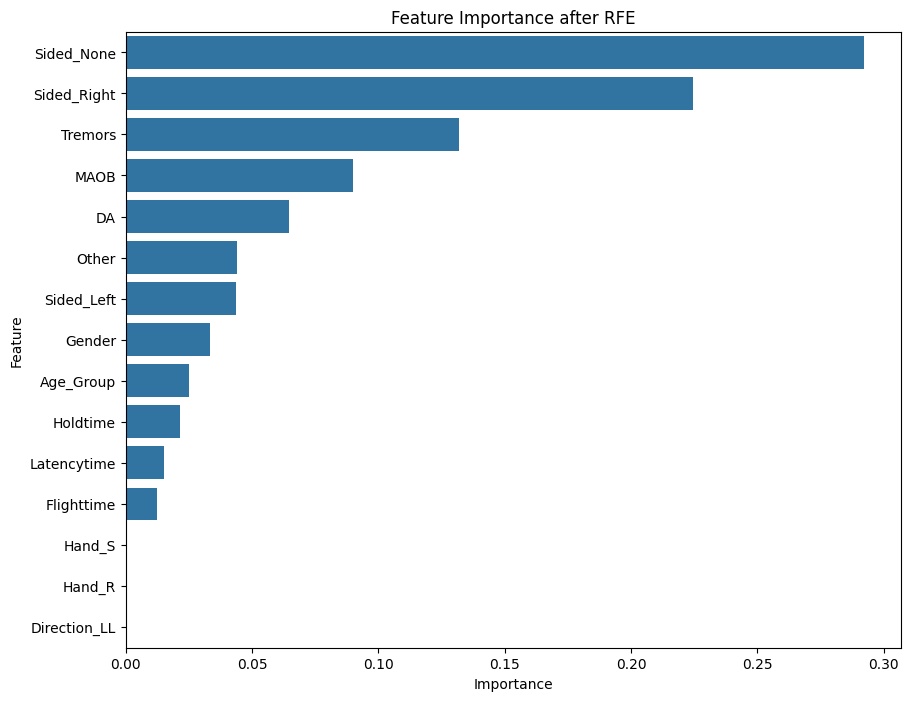

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Importance Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance after RFE')
plt.show()


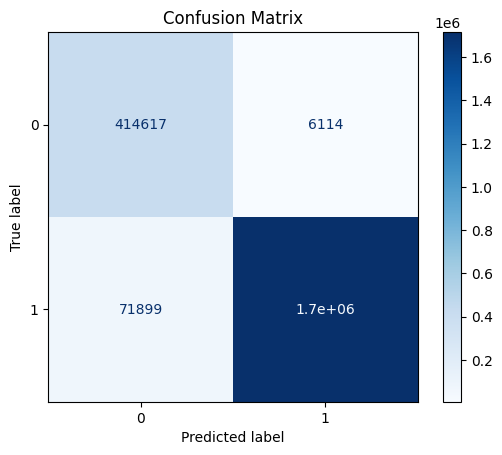

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_smote)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


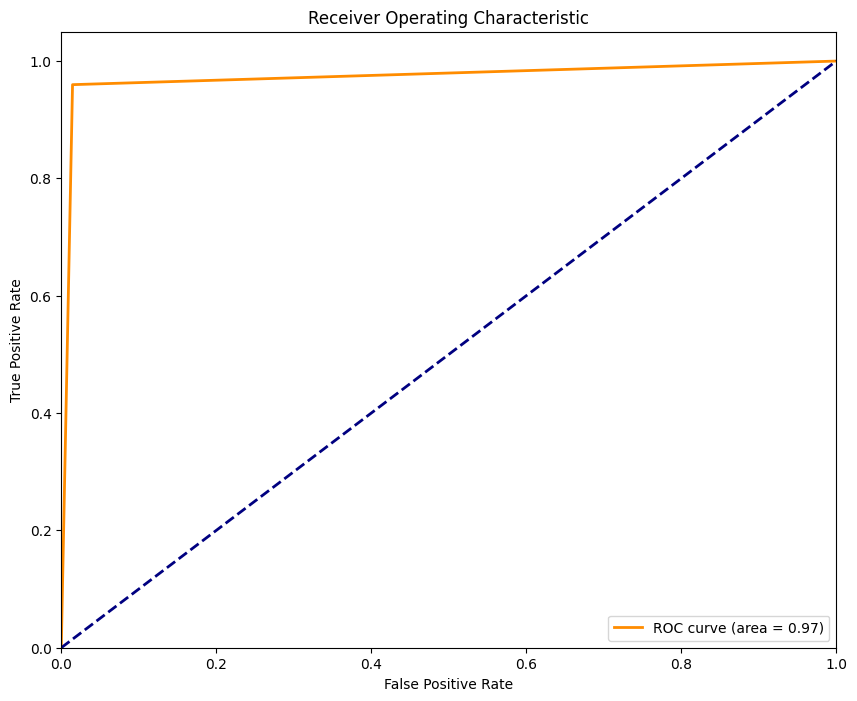

In [60]:
from sklearn.metrics import roc_curve, auc

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_smote)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


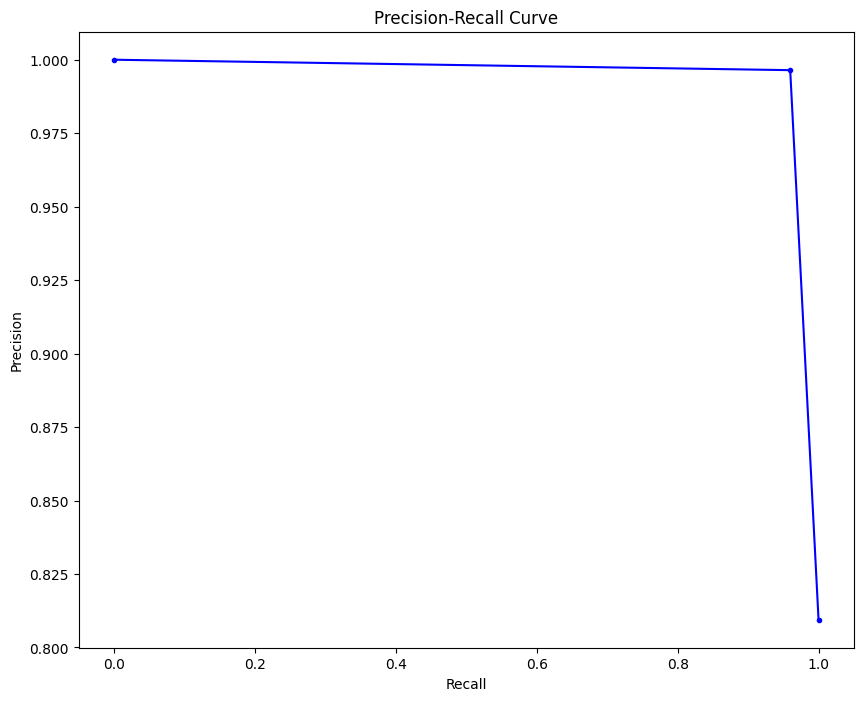

In [61]:
from sklearn.metrics import precision_recall_curve

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_smote)

plt.figure(figsize=(10, 8))
plt.plot(recall, precision, marker='.', color='blue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


# Logistic Regression

In [63]:
# Defining the Logistic Regression classifier with class weights
log_reg_classifier = LogisticRegression(random_state=42, max_iter=1000)

# Training the classifier on the original training data
log_reg_classifier.fit(X_train_smote, y_train_smote)

# Evaluating on test set
y_test_pred = log_reg_classifier.predict(X_test_rfe)
print(f'Test Accuracy: {accuracy_score(y_test, y_test_pred)}')
print(classification_report(y_test, y_test_pred))
test_roc_auc = roc_auc_score(y_test, y_test_pred)
print(f'Test ROC AUC Score: {test_roc_auc}')


Test Accuracy: 0.9496903116811942
              precision    recall  f1-score   support

           0       0.80      0.99      0.88    420731
           1       1.00      0.94      0.97   1787134

    accuracy                           0.95   2207865
   macro avg       0.90      0.97      0.93   2207865
weighted avg       0.96      0.95      0.95   2207865

Test ROC AUC Score: 0.9656548044059294


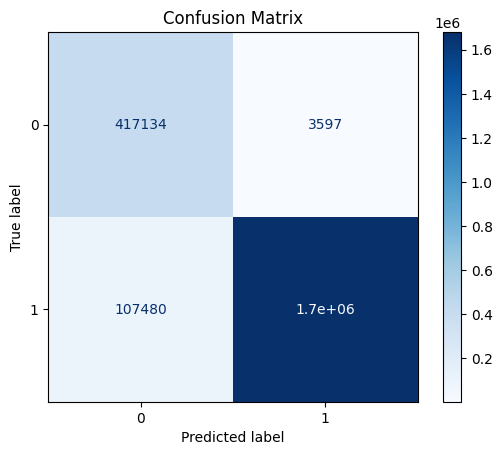

In [64]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


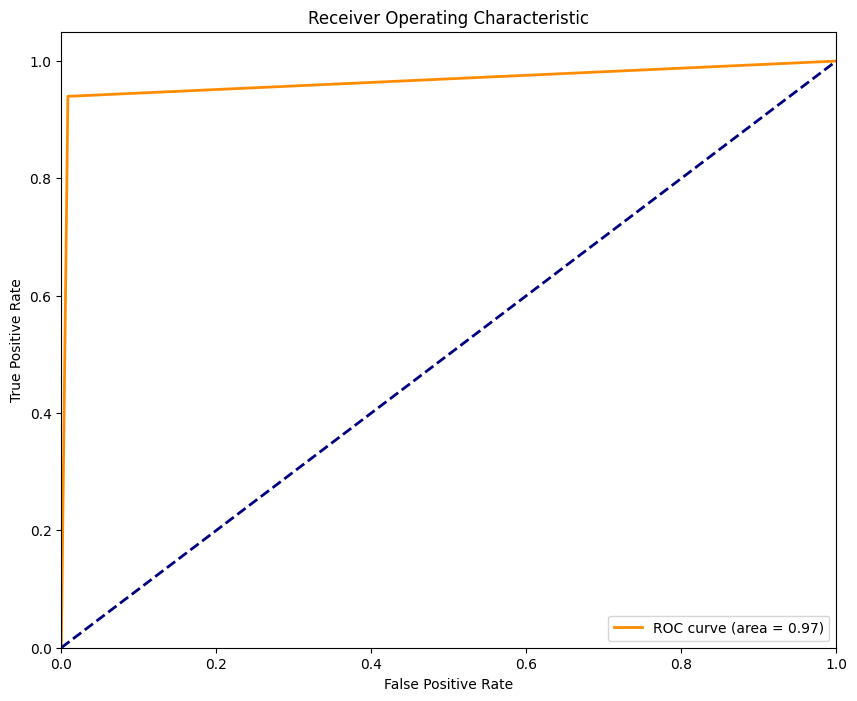

In [65]:
from sklearn.metrics import roc_curve, auc

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


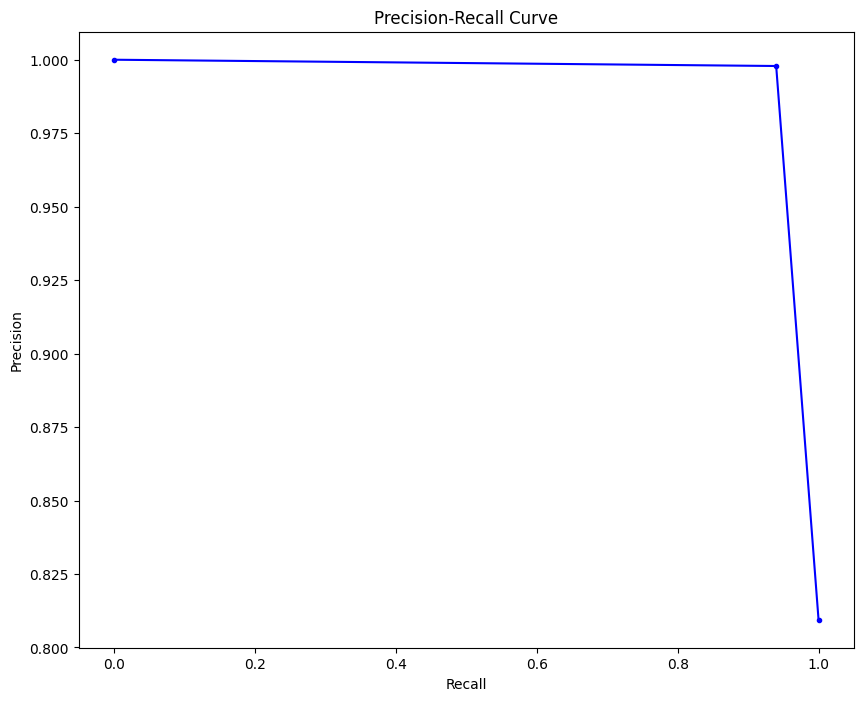

In [66]:
from sklearn.metrics import precision_recall_curve

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_test_pred)

plt.figure(figsize=(10, 8))
plt.plot(recall, precision, marker='.', color='blue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


# Without SMOTE

# Random Forest

In [69]:
# Fitting the model on SMOTE-applied RFE-reduced data

rf_classifier_no_smote = RandomForestClassifier(random_state=42)


rf_classifier_no_smote.fit(X_train_rfe, y_train)


RandomForestClassifier(random_state=42)

In [70]:
# Getting feature importance from the model after RFE
rfe_feature_importance_no_smote = rf_classifier_no_smote.feature_importances_

# Map RFE-selected features back to original features
selected_features_no_smote = X_train.columns[rfe.support_]

# Create a DataFrame for better visualization of feature importances
importance_df_no_smote = pd.DataFrame({
    'Feature': selected_features_no_smote,
    'Importance': rfe_feature_importance_no_smote
}).sort_values(by='Importance', ascending=False)

# Display the feature importance
print(importance_df_no_smote)

# Predict on the RFE-reduced test set using the model trained without SMOTE
y_pred_no_smote = rf_classifier_no_smote.predict(X_test_rfe)

# Evaluate the model's performance
print(f'Accuracy (No SMOTE): {accuracy_score(y_test, y_pred_no_smote)}')
print(classification_report(y_test, y_pred_no_smote))
roc_auc_no_smote = roc_auc_score(y_test, y_pred_no_smote)
print(f'ROC AUC Score (No SMOTE): {roc_auc_no_smote}')



         Feature  Importance
13    Sided_None    0.267585
14   Sided_Right    0.242362
4        Tremors    0.130005
6           MAOB    0.100443
5             DA    0.077573
7          Other    0.046057
12    Sided_Left    0.040434
3         Gender    0.032947
8      Age_Group    0.027472
0       Holdtime    0.016885
1    Latencytime    0.008886
2     Flighttime    0.008311
9         Hand_R    0.000379
10        Hand_S    0.000377
11  Direction_LL    0.000285
Accuracy (No SMOTE): 0.4915345820509859
              precision    recall  f1-score   support

           0       0.27      0.99      0.43    420731
           1       0.99      0.37      0.54   1787134

    accuracy                           0.49   2207865
   macro avg       0.63      0.68      0.48   2207865
weighted avg       0.86      0.49      0.52   2207865

ROC AUC Score (No SMOTE): 0.6814893320765862


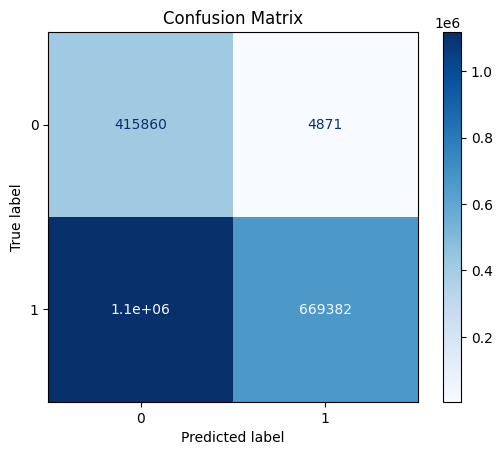

In [71]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_no_smote)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


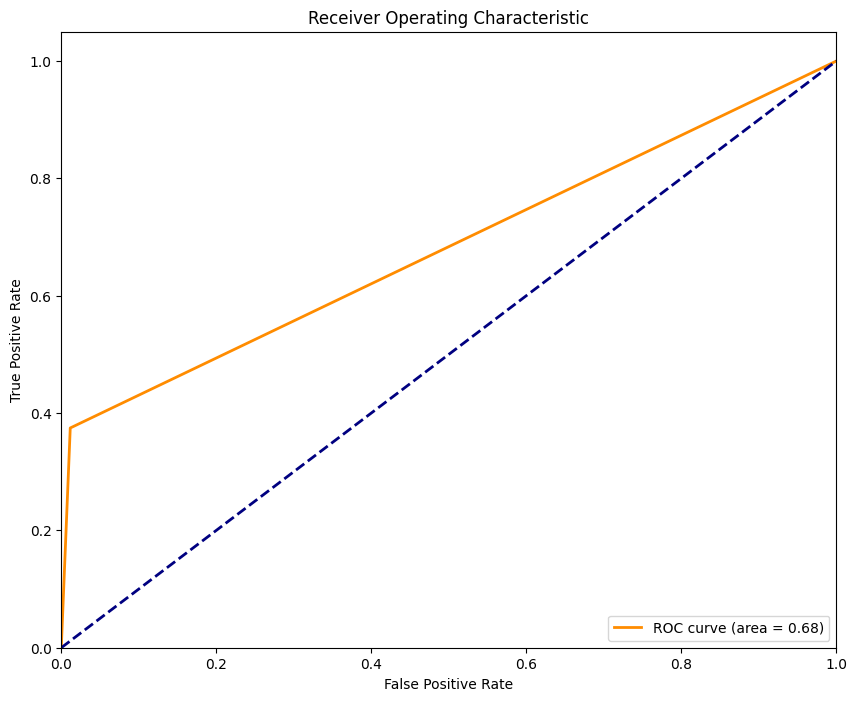

In [72]:
from sklearn.metrics import roc_curve, auc

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_no_smote)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


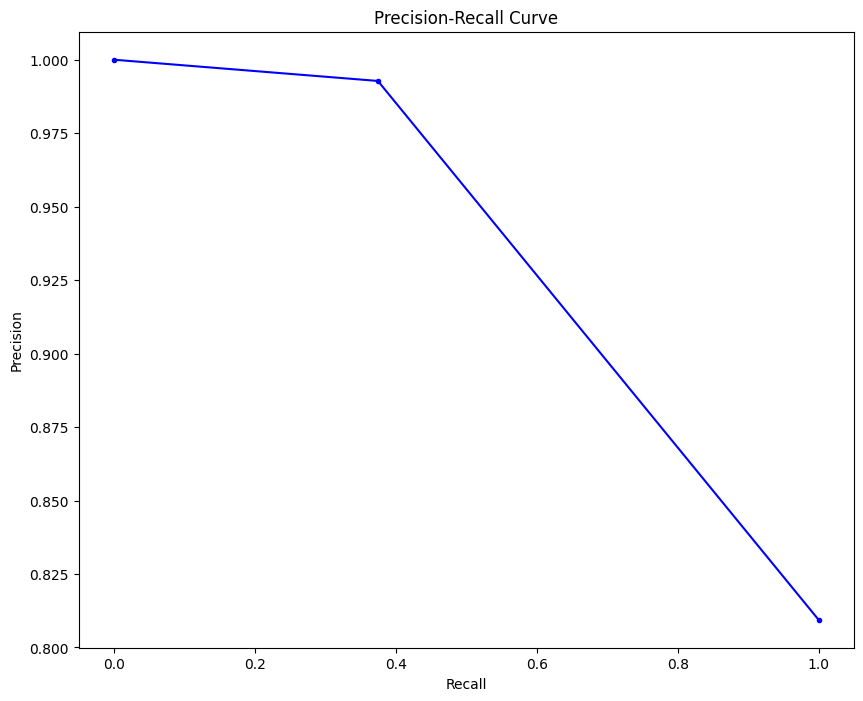

In [73]:
from sklearn.metrics import precision_recall_curve

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_no_smote)

plt.figure(figsize=(10, 8))
plt.plot(recall, precision, marker='.', color='blue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


# Logistic Regression

In [75]:
# Defining the Logistic Regression classifier with class weights
log_reg_classifier = LogisticRegression(random_state=42, max_iter=1000)

# Training the classifier on the original training data
log_reg_classifier.fit(X_train_rfe, y_train)

# Evaluating on test set
lr_y_pred_no_smote = log_reg_classifier.predict(X_test_rfe)
print(f'Accuracy (No SMOTE): {accuracy_score(y_test, lr_y_pred_no_smote)}')
print(classification_report(y_test, lr_y_pred_no_smote))
test_roc_auc = roc_auc_score(y_test, lr_y_pred_no_smote)
print(f'ROC AUC Score (No SMOTE): {test_roc_auc}')


Accuracy (No SMOTE): 0.9424000108702298
              precision    recall  f1-score   support

           0       0.77      0.99      0.87    420731
           1       1.00      0.93      0.96   1787134

    accuracy                           0.94   2207865
   macro avg       0.88      0.96      0.92   2207865
weighted avg       0.95      0.94      0.94   2207865

ROC AUC Score (No SMOTE): 0.9612023880021643


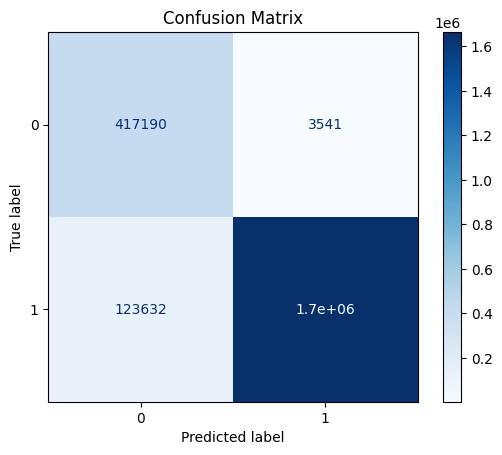

In [76]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, lr_y_pred_no_smote)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


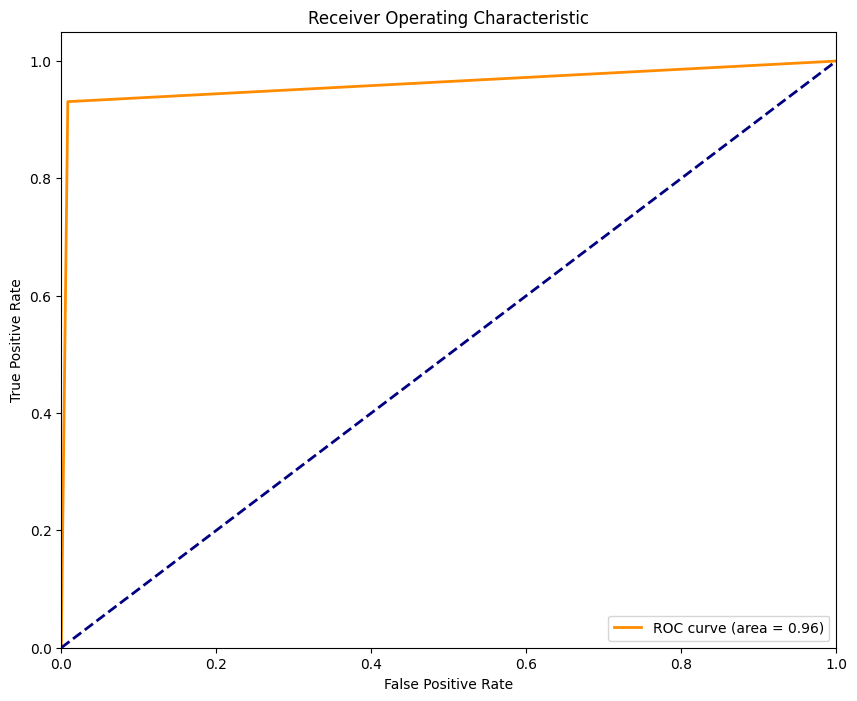

In [77]:
from sklearn.metrics import roc_curve, auc

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, lr_y_pred_no_smote)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


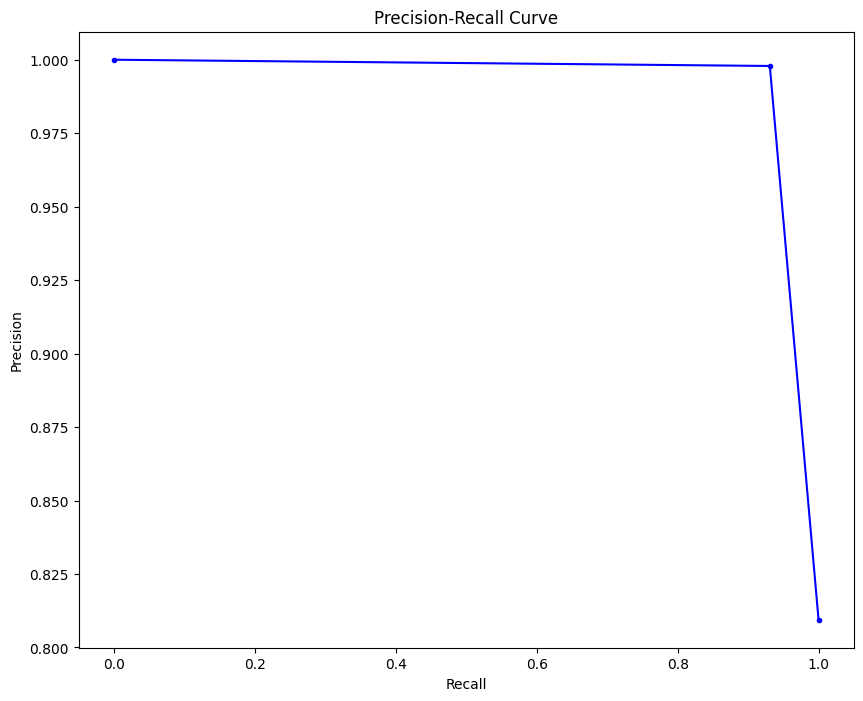

In [78]:
from sklearn.metrics import precision_recall_curve

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, lr_y_pred_no_smote)

plt.figure(figsize=(10, 8))
plt.plot(recall, precision, marker='.', color='blue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


# Selecting 10 features and 20 features to compare

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
import pandas as pd
from sklearn.feature_selection import RFE

def train_and_evaluate(features_count=None):
    # Check if specific features count is set, else use all features
    if features_count:
        # Using Random Forest for RFE
        rf_rfe = RandomForestClassifier(random_state=42)
        rfe_selector = RFE(estimator=rf_rfe, n_features_to_select=features_count)
        X_train_selected = rfe_selector.fit_transform(X_train, y_train)
        X_test_selected = rfe_selector.transform(X_test)
    else:
        # Use all features
        X_train_selected = X_train
        X_test_selected = X_test
    
    # Apply SMOTE
    smote_processor = SMOTE(random_state=42)
    X_train_balanced, y_train_balanced = smote_processor.fit_resample(X_train_selected, y_train)
    
    feature_info = "all features" if not features_count else f"top {features_count} features"
    print(f"Training with {feature_info}:")
    print("Shape of X_train after SMOTE:", X_train_balanced.shape)
    print("Class distribution after SMOTE:\n", pd.Series(y_train_balanced).value_counts())
    
    # Train Random Forest Classifier
    rf_model = RandomForestClassifier(random_state=42)
    rf_model.fit(X_train_balanced, y_train_balanced)
    y_pred_rf = rf_model.predict(X_test_selected)
    rf_probs = rf_model.predict_proba(X_test_selected)[:, 1]
    rf_roc_auc = roc_auc_score(y_test, rf_probs)
    fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
    
    # Train Logistic Regression Classifier
    lr_model = LogisticRegression(random_state=42, max_iter=1000)
    lr_model.fit(X_train_balanced, y_train_balanced)
    y_pred_lr = lr_model.predict(X_test_selected)
    lr_probs = lr_model.predict_proba(X_test_selected)[:, 1]
    lr_roc_auc = roc_auc_score(y_test, lr_probs)
    fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
    
    # Display results
    print("\nRandom Forest:")
    print(f'Accuracy: {accuracy_score(y_test, y_pred_rf)}')
    print(classification_report(y_test, y_pred_rf))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
    print(f'ROC AUC Score: {rf_roc_auc}')

    print("\nLogistic Regression:")
    print(f'Accuracy: {accuracy_score(y_test, y_pred_lr)}')
    print(classification_report(y_test, y_pred_lr))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
    print(f'ROC AUC Score: {lr_roc_auc}')
    
    # Plot ROC curves
    plt.figure(figsize=(10, 8))
    plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (area = {rf_roc_auc:.2f})')
    plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (area = {lr_roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()


Training with top 10 features:
Shape of X_train after SMOTE: (3710274, 10)
Class distribution after SMOTE:
 Parkinsons
1    1855137
0    1855137
Name: count, dtype: int64

Random Forest:
Accuracy: 0.49184619530632534
              precision    recall  f1-score   support

           0       0.27      0.99      0.43    420731
           1       0.99      0.37      0.54   1787134

    accuracy                           0.49   2207865
   macro avg       0.63      0.68      0.49   2207865
weighted avg       0.86      0.49      0.52   2207865

Confusion Matrix:
 [[ 416582    4149]
 [1117786  669348]]
ROC AUC Score: 0.9631951540633992

Logistic Regression:
Accuracy: 0.9432727997409261
              precision    recall  f1-score   support

           0       0.77      0.99      0.87    420731
           1       1.00      0.93      0.96   1787134

    accuracy                           0.94   2207865
   macro avg       0.89      0.96      0.92   2207865
weighted avg       0.96      0.94      0.

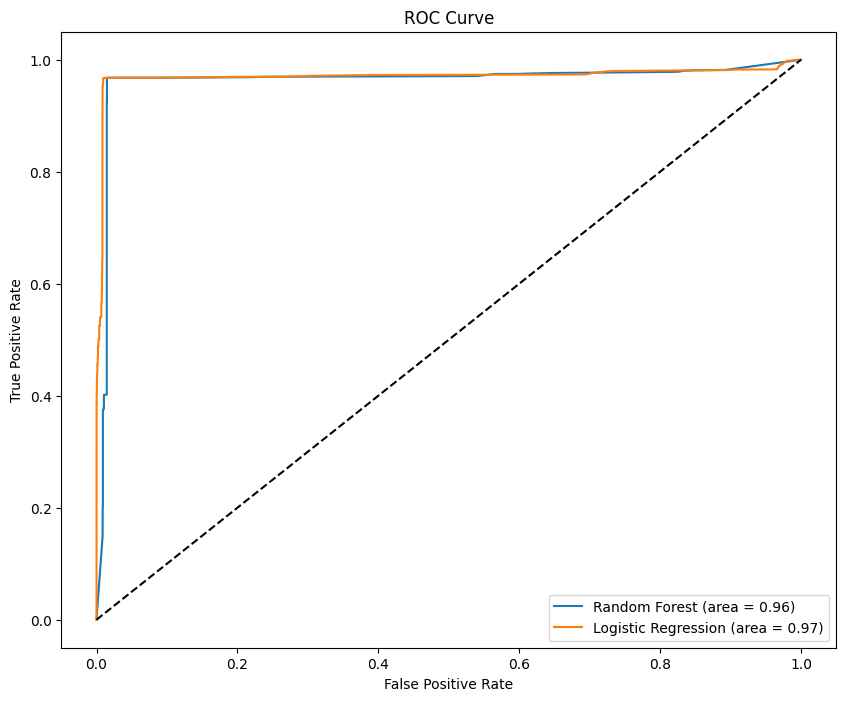

In [81]:
train_and_evaluate(10)

Training with top 20 features:
Shape of X_train after SMOTE: (3710274, 20)
Class distribution after SMOTE:
 Parkinsons
1    1855137
0    1855137
Name: count, dtype: int64

Random Forest:
Accuracy: 0.5398350895548415
              precision    recall  f1-score   support

           0       0.29      0.98      0.45    420731
           1       0.99      0.44      0.60   1787134

    accuracy                           0.54   2207865
   macro avg       0.64      0.71      0.53   2207865
weighted avg       0.86      0.54      0.58   2207865

Confusion Matrix:
 [[ 414363    6368]
 [1009614  777520]]
ROC AUC Score: 0.9663472389527701

Logistic Regression:
Accuracy: 0.95949118265836
              precision    recall  f1-score   support

           0       0.83      0.99      0.90    420731
           1       1.00      0.95      0.97   1787134

    accuracy                           0.96   2207865
   macro avg       0.91      0.97      0.94   2207865
weighted avg       0.97      0.96      0.96 

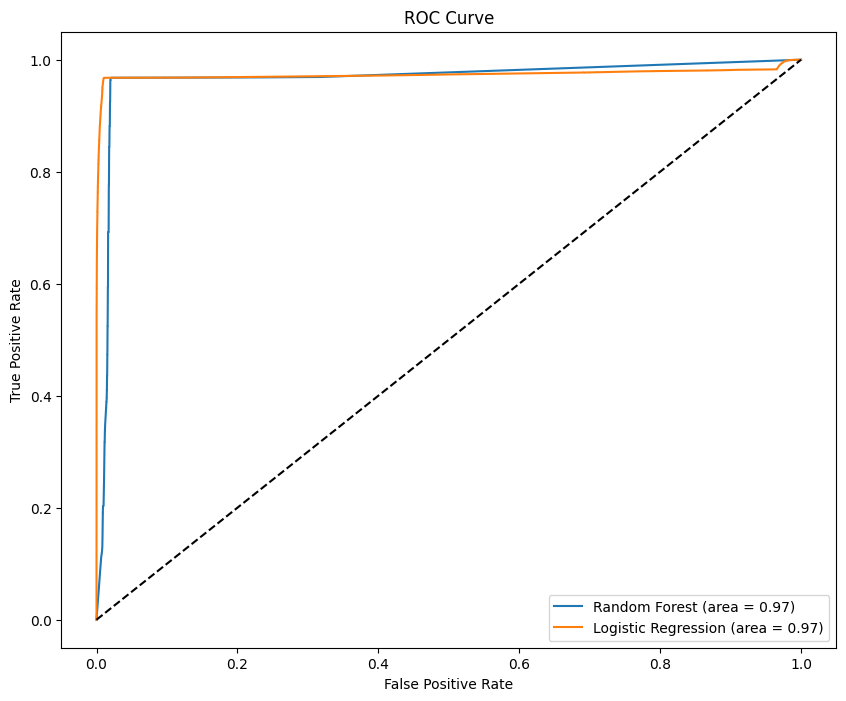

In [82]:
train_and_evaluate(20)

## ✅ Conclusion

The Random Forest model achieved the highest performance, demonstrating that keystroke dynamics can effectively detect early-stage Parkinson’s Disease.

Feature selection and SMOTE significantly improved model performance.